In [1]:
import pandas as pd
import numpy as np
pd.set_option("display.max_rows", None, "display.max_columns", None)

In [2]:
df = pd.read_csv('../input/titanic/train.csv')
df_original = df.copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

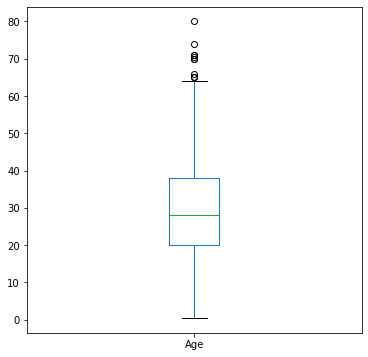

In [5]:
df['Age'].plot(kind='box', figsize=(6,6))

In [6]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [7]:
df_nullage = df[['Age', 'SibSp', 'Parch']][df['Age'].isnull()]
df_nullage

,Age,SibSp,Parch
5,NaN,0,0
17,NaN,0,0
19,NaN,0,0
26,NaN,0,0
28,NaN,0,0
29,NaN,0,0
31,NaN,1,0
32,NaN,0,0
36,NaN,0,0
42,NaN,0,0


In [8]:
df_nullagewithfamily = df[['Age', 'SibSp', 'Parch']][df['Age'].isnull() & (df['SibSp'] + df['Parch'])>0]
df_nullagewithfamily

,Age,SibSp,Parch
31,NaN,1,0
46,NaN,1,0
109,NaN,1,0
166,NaN,0,1
186,NaN,1,0
214,NaN,1,0
240,NaN,1,0
241,NaN,1,0
334,NaN,1,0
347,NaN,1,0


In [9]:
print(df_nullage.shape[0], '  ', df_nullagewithfamily.shape[0])

177    24


In [10]:
df = df[df['Age'].notnull()]
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64

In [11]:
df['Embarked'][df['Embarked'].isnull()] = df['Embarked'].value_counts().idxmax()
df['Embarked'].value_counts()

S    556
C    130
Q     28
Name: Embarked, dtype: int64

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         0
dtype: int64

In [13]:
df.drop('Cabin', axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [14]:
df.drop('Name', axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,female,35.0,1,0,113803,53.1000,S
4,5,0,3,male,35.0,0,0,373450,8.0500,S


In [15]:
df.drop(['PassengerId', 'Ticket'], axis=1, inplace=True)
from sklearn.preprocessing import StandardScaler

In [16]:
Fare = df[['Fare']]
df['Fare'] = StandardScaler().fit_transform(Fare)
Age = df[['Age']]
df['Age'] = StandardScaler().fit_transform(Age)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,-0.530377,1,0,-0.518978,S
1,1,1,female,0.571831,1,0,0.691897,C
2,1,3,female,-0.254825,0,0,-0.506214,S
3,1,1,female,0.365167,1,0,0.348049,S
4,0,3,male,0.365167,0,0,-0.503850,S


In [17]:
df = pd.concat([df, pd.get_dummies(df[['Sex', 'Embarked']])], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,male,-0.530377,1,0,-0.518978,S,0,1,0,0,1
1,1,1,female,0.571831,1,0,0.691897,C,1,0,1,0,0
2,1,3,female,-0.254825,0,0,-0.506214,S,1,0,0,0,1
3,1,1,female,0.365167,1,0,0.348049,S,1,0,0,0,1
4,0,3,male,0.365167,0,0,-0.503850,S,0,1,0,0,1


In [18]:
df.drop(['Sex', 'Embarked'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,-0.530377,1,0,-0.518978,0,1,0,0,1
1,1,1,0.571831,1,0,0.691897,1,0,1,0,0
2,1,3,-0.254825,0,0,-0.506214,1,0,0,0,1
3,1,1,0.365167,1,0,0.348049,1,0,0,0,1
4,0,3,0.365167,0,0,-0.503850,0,1,0,0,1


In [19]:
X = df.drop('Survived', axis=1)
y = df['Survived']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [20]:
from sklearn.ensemble import RandomForestClassifier
r = []
for k in range(10,100):
    RFC = RandomForestClassifier(n_estimators = k).fit(x_train,y_train)
    r_2 = RFC.score(x_test, y_test)
    r.append(r_2)
    print(k, r_2)

10 0.8181818181818182
11 0.7972027972027972
12 0.8321678321678322
13 0.8251748251748252
14 0.8321678321678322
15 0.7902097902097902
16 0.8181818181818182
17 0.8181818181818182
18 0.8111888111888111
19 0.8111888111888111
20 0.8181818181818182
21 0.8181818181818182
22 0.8181818181818182
23 0.8041958041958042
24 0.8251748251748252
25 0.8321678321678322
26 0.8181818181818182
27 0.7832167832167832
28 0.8111888111888111
29 0.7972027972027972
30 0.8181818181818182
31 0.8251748251748252
32 0.8181818181818182
33 0.7902097902097902
34 0.8181818181818182
35 0.8251748251748252
36 0.8181818181818182
37 0.8181818181818182
38 0.8111888111888111
39 0.8321678321678322
40 0.8111888111888111
41 0.8041958041958042
42 0.8041958041958042
43 0.7972027972027972
44 0.8111888111888111
45 0.8251748251748252
46 0.8251748251748252
47 0.8251748251748252
48 0.8251748251748252
49 0.8111888111888111
50 0.7972027972027972
51 0.8181818181818182
52 0.8321678321678322
53 0.8251748251748252
54 0.7972027972027972
55 0.83216

In [21]:
for i, n in enumerate(r):
    if n == np.max(r):
        print(i, n)

61 0.8461538461538461


In [22]:
RFC = RandomForestClassifier(n_estimators = 42).fit(x_train,y_train)
yhat = RFC.predict(x_test)
yhat[0:5]

array([0, 1, 0, 0, 1])

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, yhat)

Text(69.0, 0.5, 'Actual')

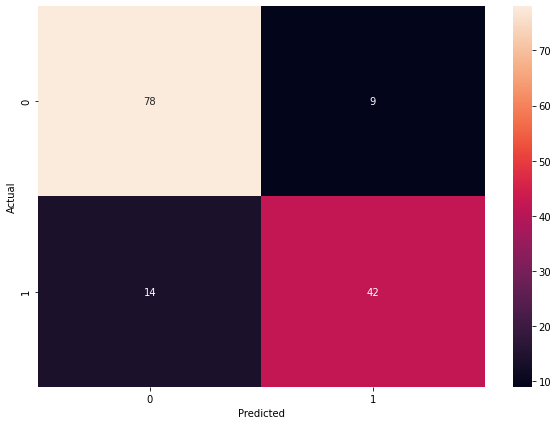

In [24]:
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [25]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat)

0.6461538461538462

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat, labels=[1,0]))

[[42 14]
 [ 9 78]]


Confusion matrix, without normalization
[[42 14]
 [ 9 78]]


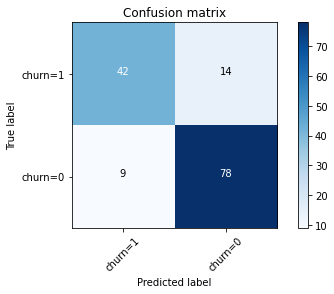

In [27]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['churn=1','churn=0'],normalize= False,  title='Confusion matrix')

In [28]:
RFC = RandomForestClassifier(n_estimators = 42).fit(X,y)

In [29]:
df_test = pd.read_csv('../input/titanic/test.csv')
df_test_copy = df_test.copy()
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [30]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [31]:
df_test.drop(['PassengerId','Name'], axis=1, inplace=True)
df_test.head()
df_test.drop('Cabin', axis=1, inplace=True)
df_test['Age'].replace(np.nan, df_test['Age'].astype('float').mean(axis=0), inplace=True)
df_test['Fare'].replace(np.nan, df_test['Fare'].astype('float').mean(axis=0), inplace=True)
df_test.drop('Ticket', axis=1, inplace=True)
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [32]:
df_test = pd.concat([df_test,pd.get_dummies(df_test[['Sex', 'Embarked']])], axis=1)
df_test.drop(['Sex', 'Embarked'], axis=1, inplace=True)
df_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,0,1,0,1,0
1,3,47.0,1,0,7.0000,1,0,0,0,1
2,2,62.0,0,0,9.6875,0,1,0,1,0
3,3,27.0,0,0,8.6625,0,1,0,0,1
4,3,22.0,1,1,12.2875,1,0,0,0,1


In [33]:
Fare = df_test[['Fare']]
df_test['Fare'] = StandardScaler().fit_transform(Fare)
Age = df_test[['Age']]
df_test['Age'] = StandardScaler().fit_transform(Age)
df_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,0.334993,0,0,-0.498407,0,1,0,1,0
1,3,1.325530,1,0,-0.513274,1,0,0,0,1
2,2,2.514175,0,0,-0.465088,0,1,0,1,0
3,3,-0.259330,0,0,-0.483466,0,1,0,0,1
4,3,-0.655545,1,1,-0.418471,1,0,0,0,1


In [34]:
yhat = RFC.predict(df_test)
print(yhat[0:10])

[0 0 0 0 1 0 1 0 1 0]


In [35]:
df_test['Label'] = yhat
df_predict = pd.concat([df_test_copy['PassengerId'], df_test['Label']], axis=1)
df_predict.columns = ['PassengerId','Survived']
df_predict.set_index('PassengerId', drop=True, inplace=True) 

In [36]:
predicted = df_predict.to_csv('Prediction.csv')

In [37]:
df_predict

,Survived
PassengerId,
892,0
893,0
894,0
895,0
896,1
897,0
898,1
899,0
900,1
